# Problem 1

In [4]:
def bisection(f, a, b, tol=1e-8, max_iter=100):
    """
    Finds a root of f in [a, b] using the Bisection Method.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    for k in range(1, max_iter + 1):
        c = (a + b) / 2

        # Stopping criteria: interval size or function value
        if abs(b - a) / 2 < tol or abs(f(c)) < tol:
            return c, k

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return (a + b) / 2, max_iter


In [5]:
def regula_falsi(f, a, b, tol=1e-8, max_iter=100):
    """
    Finds a root of f in [a, b] using the Regula Falsi (False Position) Method.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    c = a
    for k in range(1, max_iter + 1):
        c_prev = c
        c = (a * f(b) - b * f(a)) / (f(b) - f(a))

        if abs(c - c_prev) < tol or abs(f(c)) < tol:
            return c, k

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return c, max_iter


## Part (a) -> Bugs in the given code

In the bisection code
- range in wrong
    ```python
    for k in range(1, max_iter + 1):
    ```

- ```python
    if abs(b - a) / 2 < tol or abs(f(c)) < tol:
    ```

In the false position code
- Intial check is not present 
    ```python
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    ```
- Not making c = previous (i - 1)th root
    ```python
    c = a
    for k in range(1, max_iter + 1):
        c_prev = c
    ```

-  opposite side check not present
    ```python
    if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    ```

## Test cases part (b)

In [7]:
f = lambda x: (x - 1)**3

root, iters = bisection(f, a=0, b=3)
print(f"Bisection root: x = {root:.8f}  (found in {iters} iterations)")
print(f"Check: f(root) = {f(root):.2e}")

root, iters = regula_falsi(f, a=0, b=3)
print(f"Regula Falsi root: x = {root:.8f}  (found in {iters} iterations)")
print(f"Check: f(root) = {f(root):.2e}")


Bisection root: x = 1.00195312  (found in 9 iterations)
Check: f(root) = 7.45e-09
Regula Falsi root: x = 0.86914475  (found in 100 iterations)
Check: f(root) = -2.24e-03


### Explanantion
- Bisection converges slowly but at a constant rate as it continously halves the interval at each iteration

- Standard regula falsi suffers from single end point stagnation as the graph between the interval is skewed and the the root lies on the other end and since the straight line drawn through the two points cuts much slower to the other end the shifting of root is much slower

### Test case 2

In [ ]:
f = lambda x: 1/(x - 2)

root, iters = bisection(f, a=1, b=3)
print(f"Bisection root: x = {root:.8f}  (found in {iters} iterations)")
print(f"Check: f(root) = {f(root):.2e}")

root, iters = regula_falsi(f, a=1, b=3)
print(f"Regula Falsi root: x = {root:.8f}  (found in {iters} iterations)")
print(f"Check: f(root) = {f(root):.2e}")

ZeroDivisionError: float division by zero

- Due to root being 2 which makes the denominator zero becuse of which the method are doing division by zero and thus causing ZeroDivisionError: float division by zero 

- We can detect vertical asymptotes/discontinuities by plotting the graph before hand or doing manual inspection

## Part (c) -> Illinois Modification

In [10]:
def illinois_method(f, a, b, tol=1e-8, max_iter=100):
    """
    Illinois Method — a modified Regula Falsi that fixes stagnation.
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    fa, fb = f(a), f(b)
    side = 0          # tracks which side was kept last iteration: -1 = a, +1 = b
    c = a

    for k in range(1, max_iter + 1):
        c_prev = c
        c = (a * fb - b * fa) / (fb - fa)
        fc = f(c)

        if abs(c - c_prev) < tol or abs(fc) < tol:
            return c, k

        if fa * fc < 0:
            # root is in [a, c] -> b becomes c
            b, fb = c, fc

            # --- Detect Stagnation: 'a' side reused twice in a row ---
            if side == -1:
                fa *= 0.5          # --- Half the Weight ---
            side = -1               # --- Restore Speed (next iter uses halved fa) ---
        else:
            # root is in [c, b] -> a becomes c
            a, fa = c, fc

            # --- Detect Stagnation: 'b' side reused twice in a row ---
            if side == 1:
                fb *= 0.5          # --- Half the Weight ---
            side = 1                # --- Restore Speed ---

    return c, max_iter

In [11]:
f = lambda x: x**10 - 1

root_rf, iters_rf = regula_falsi(f, a=0, b=1.3)
root_il, iters_il = illinois_method(f, a=0, b=1.3)

print(f"Regula Falsi:  x = {root_rf:.8f}  in {iters_rf} iterations")
print(f"Illinois:      x = {root_il:.8f}  in {iters_il} iterations")

Regula Falsi:  x = 0.99999997  in 74 iterations
Illinois:      x = 1.00000000  in 13 iterations


# Problem 3

In [19]:
import numpy as np
# ---------------------------------------------------------------
# 0a. Vector norm  (replacement for np.linalg.norm on a 1D array)
# ---------------------------------------------------------------
def vector_norm(v, p=2):
    """
    Computes the p-norm of a vector v WITHOUT using np.linalg.norm.

    p = 1        -> sum of absolute values
    p = np.inf   -> maximum absolute value
    otherwise    -> (sum |v_i|^p)^(1/p)
    """
    v = np.asarray(v, dtype=float).flatten()

    if p == np.inf:
        return max(abs(vi) for vi in v)
    if p == 1:
        return sum(abs(vi) for vi in v)

    total = sum(abs(vi) ** p for vi in v)
    return total ** (1.0 / p)


# ---------------------------------------------------------------
# 0b. Power iteration (helper for the matrix 2-norm)
# ---------------------------------------------------------------
def _power_iteration_largest_eigenvalue(M, num_iter=5000, tol=1e-12):
    """
    Estimates the largest eigenvalue of a symmetric positive semi-definite
    matrix M using the Power Iteration method (no np.linalg.eig used).
    """
    n = M.shape[0]
    v = np.ones(n)
    v = v / vector_norm(v, 2)

    lam_old = 0.0
    for _ in range(num_iter):
        w = np.dot(M, v)
        norm_w = vector_norm(w, 2)
        if norm_w < 1e-300:
            return 0.0
        v = w / norm_w
        lam = np.dot(v, np.dot(M, v))  # Rayleigh quotient
        if abs(lam - lam_old) < tol:
            break
        lam_old = lam
    return lam


# ---------------------------------------------------------------
# 0c. Matrix norm  (replacement for np.linalg.norm on a 2D array)
# ---------------------------------------------------------------
def matrix_norm(A, p=2):
    """
    Computes the induced p-norm of a matrix A WITHOUT using np.linalg.norm.

    p = 1        -> maximum absolute column sum
    p = np.inf   -> maximum absolute row sum
    p = 'fro'    -> Frobenius norm  sqrt(sum of squares of all entries)
    p = 2        -> spectral norm = sqrt(largest eigenvalue of A^T A),
                     found via power iteration
    """
    A = np.asarray(A, dtype=float)
    n, m = A.shape

    if p == 1:
        return max(sum(abs(A[i, j]) for i in range(n)) for j in range(m))

    if p == np.inf:
        return max(sum(abs(A[i, j]) for j in range(m)) for i in range(n))

    if p == 'fro':
        return sum(A[i, j] ** 2 for i in range(n) for j in range(m)) ** 0.5

    if p == 2:
        AtA = np.dot(A.T, A)
        lam_max = _power_iteration_largest_eigenvalue(AtA)
        return max(lam_max, 0.0) ** 0.5

    raise ValueError(f"Unsupported norm type: {p}")


# ---------------------------------------------------------------
# 0d. Solve a linear system  (replacement for np.linalg.solve)
# ---------------------------------------------------------------
def gaussian_elimination_solve(A, b):
    """
    Solves A x = b via Gaussian elimination with partial pivoting,
    WITHOUT using np.linalg.solve.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).flatten()
    n = len(b)

    # Build augmented matrix [A | b]
    M = np.hstack([A, b.reshape(-1, 1)])

    # Forward elimination with partial pivoting
    for k in range(n):
        pivot_row = k + int(np.argmax(np.abs(M[k:, k])))
        if pivot_row != k:
            M[[k, pivot_row]] = M[[pivot_row, k]]

        if abs(M[k, k]) < 1e-14:
            raise ArithmeticError("Matrix is singular - cannot solve system")

        for i in range(k + 1, n):
            factor = M[i, k] / M[k, k]
            M[i, k:] -= factor * M[k, k:]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (M[i, -1] - np.dot(M[i, i + 1:n], x[i + 1:n])) / M[i, i]

    return x


# ---------------------------------------------------------------
# 0e. Determinant  (replacement for np.linalg.det)
# ---------------------------------------------------------------
def determinant(A):
    """
    Computes det(A) via Gaussian elimination (product of pivots, with a
    sign flip for every row swap), WITHOUT using np.linalg.det.
    """
    M = np.array(A, dtype=float)
    n = M.shape[0]
    sign = 1

    for k in range(n):
        pivot_row = k + int(np.argmax(np.abs(M[k:, k])))
        if pivot_row != k:
            M[[k, pivot_row]] = M[[pivot_row, k]]
            sign *= -1

        if abs(M[k, k]) < 1e-14:
            return 0.0  # singular matrix

        for i in range(k + 1, n):
            factor = M[i, k] / M[k, k]
            M[i, k:] -= factor * M[k, k:]

    det = sign
    for i in range(n):
        det *= M[i, i]
    return det


# ---------------------------------------------------------------
# 0f. Matrix inverse  (replacement for np.linalg.inv)
# ---------------------------------------------------------------
def matrix_inverse(A):
    """
    Computes A^-1 via Gauss-Jordan elimination on [A | I],
    WITHOUT using np.linalg.inv.
    """
    A = np.array(A, dtype=float)
    n = A.shape[0]
    aug = np.hstack([A, np.eye(n)])

    for k in range(n):
        pivot_row = k + int(np.argmax(np.abs(aug[k:, k])))
        if pivot_row != k:
            aug[[k, pivot_row]] = aug[[pivot_row, k]]

        if abs(aug[k, k]) < 1e-14:
            raise ArithmeticError("Matrix is singular - cannot invert")

        aug[k] = aug[k] / aug[k, k]
        for i in range(n):
            if i != k:
                aug[i] -= aug[i, k] * aug[k]

    return aug[:, n:]


In [47]:
def condition_number(A, p_norm=2):
    """
    Computes the condition number of a square matrix A:
        cond(A) = ||A|| * ||A^-1||
    """
    A = np.array(A, dtype=float)

    # IF determinant(A) == 0 THEN RETURN Infinity
    if abs(determinant(A)) < 1e-14:
        return np.inf

    A_inv = matrix_inverse(A)                    # A_inv = Inverse(A)
    norm_A = matrix_norm(A, p_norm)               # norm_A = MatrixNorm(A, p_norm)
    norm_A_inv = matrix_norm(A_inv, p_norm)       # norm_A_inv = MatrixNorm(A_inv, p_norm)

    cond_A = norm_A * norm_A_inv
    return cond_A


In [61]:
def multivariable_newton_raphson(F_func, J_func, x0, tol=1e-8,
                                  max_iter=100, max_cond=1e12):
    """
    Solves a nonlinear vector system F(x) = 0 using multi-variable
    Newton-Raphson.
    """
    x = np.array(x0, dtype=float)
    residual_history = []

    for k in range(1, max_iter + 1):
        F = F_func(x)
        res_norm = vector_norm(F, 2)
        residual_history.append(res_norm)

        # Stopping criterion based on residual norm
        if res_norm < tol:
            return x, k, residual_history

        J = J_func(x)
        cond_J = condition_number(J, p_norm=2)

        # Check matrix ill-conditioning
        if cond_J > max_cond:
            raise ArithmeticError("Jacobian matrix is singular or ill-conditioned")

        # Solve linear system J * delta_x = -F (avoid direct matrix inversion)
        delta_x = gaussian_elimination_solve(J, -F)

        x = x + delta_x

        # Stopping criterion based on step magnitude
        if vector_norm(delta_x, 2) < tol:
            return x, k, residual_history

    raise RuntimeError("Multi-Variable Newton-Raphson did not converge")


In [62]:
def F_func(v):
    x, y, z = v
    return np.array([x**2 + y**2 + z**2 - 9,
                     x**2 + 2*y**2 - z - 2,
                     x + y + z - 3
                     ], dtype=float)

def J_func(v):
    x, y, z = v
    return np.array([[2*x, 2*y, 2*z],
                      [2*x, 4*y, -1],
                      [1, 1, 1]
                      ], dtype=float)



In [90]:
root, iters, residual_history = multivariable_newton_raphson(
    F_func, J_func, x0=[0.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


ArithmeticError: Jacobian matrix is singular or ill-conditioned

In [64]:
root, iters, residual_history = multivariable_newton_raphson(
    F_func, J_func, x0=[0.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)



ArithmeticError: Jacobian matrix is singular or ill-conditioned

### why the above two x0 are causing error?
- Because of the chosen x0 = [1, 1, 1] or x0 = [0, 0, 0] the jacobican matrix becomes singular i.e its determinant becomes 0 therefore the condition number is becoming infinity and since infinity > max_cond the code raise ArithmeticError

## Part (c) --> Finite Difference Jacobian

In [65]:

def jacobian(F,x, eps = 1e-8):
    """Jacobian matrix by centered differences.
    """
    x = np.asarray(x, dtype=float)
    f0 = np.asarray(F(x), dtype=float)
    J = np.zeros((f0.size, x.size))
    for j in range(x.size):
        s = eps * max(1.0, abs(x[j]))
        xp, xm = x.copy(), x.copy()
        xp[j] += s
        xm[j] -= s
        J[:, j] = (np.asarray(F(xp), dtype=float) - np.asarray(F(xm), dtype=float)) / (2 * s)
    return J

In [68]:
def multivariable_newton_raphson_central(F_func, J_func, x0, tol=1e-8,
                                  max_iter=100, max_cond=1e12):
    """
    Solves a nonlinear vector system F(x) = 0 using multi-variable
    Newton-Raphson.
    """
    x = np.array(x0, dtype=float)
    residual_history = []

    for k in range(1, max_iter + 1):
        F = F_func(x)
        res_norm = vector_norm(F, 2)
        residual_history.append(res_norm)

        # Stopping criterion based on residual norm
        if res_norm < tol:
            return x, k, residual_history

        J = J_func(F_func, x)
        cond_J = condition_number(J, p_norm=2)

        # Check matrix ill-conditioning
        if cond_J > max_cond:
            raise ArithmeticError("Jacobian matrix is singular or ill-conditioned")

        # Solve linear system J * delta_x = -F (avoid direct matrix inversion)
        delta_x = gaussian_elimination_solve(J, -F)

        x = x + delta_x

        # Stopping criterion based on step magnitude
        if vector_norm(delta_x, 2) < tol:
            return x, k, residual_history

    raise RuntimeError("Multi-Variable Newton-Raphson did not converge")


In [83]:
root, iters, residual_history = multivariable_newton_raphson(
    F_func, J_func, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


root1, iters1, residual_history1 = multivariable_newton_raphson_central(
    F_func, jacobian, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


print(f"Analytical Jacobian -> Root: x = {root[0]:.8f}, y = {root[1]:.8f}, z = {root[2]:.8f}  (in {iters} iterations)")
print(f"central  Difference Jacobian -> Root: x = {root1[0]:.8f}, y = {root1[1]:.8f}, z = {root1[2]:.8f}  (in {iters1} iterations)")

Analytical Jacobian -> Root: x = 1.59558269, y = -0.95126071, z = 2.35567802  (in 9 iterations)
central  Difference Jacobian -> Root: x = 1.59558269, y = -0.95126071, z = 2.35567802  (in 9 iterations)


## Plotting and Vizualization Part(d)

In [84]:
import matplotlib.pyplot as plt

def plot(residuals_analytical, residuals_numerical):
    """
    Compares convergence trajectories (residual norm vs. iteration)
    between Analytical and Finite-Difference Jacobians.
    """
    plt.figure(figsize=(8, 5))
    plt.semilogy(range(1, len(residuals_analytical) + 1), residuals_analytical,
                 's-', label='Analytical Jacobian', color='#2B6CB0', lw=2)
    plt.semilogy(range(1, len(residuals_numerical) + 1), residuals_numerical,
                 '^-', label='Numerical (FD) Jacobian', color='#38A169', lw=2)
    plt.xlabel('Iteration Index ($k$)', fontsize=11, fontweight='bold')
    plt.ylabel('Residual Norm $\\|F(x_k)\\|_2$ (log scale)', fontsize=11, fontweight='bold')
    plt.title('Problem 3: Newton-Raphson Residual Convergence Trajectory',
              fontsize=12, fontweight='bold', color='#1A365D')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('problem_3_residuals.png', dpi=300)
    plt.show()


In [85]:
root, iters, residual_history = multivariable_newton_raphson(
    F_func, J_func, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


root1, iters1, residual_history1 = multivariable_newton_raphson_central(
    F_func, jacobian, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)

print(f"Analytical Jacobian -> Root: x = {root[0]:.8f}, y = {root[1]:.8f}  (in {iters} iterations)")
print(f"central  Difference Jacobian -> Root: x = {root1[0]:.8f}, y = {root1[1]:.8f}  (in {iters1} iterations)")

Analytical Jacobian -> Root: x = 1.59558269, y = -0.95126071  (in 9 iterations)
central  Difference Jacobian -> Root: x = 1.59558269, y = -0.95126071  (in 9 iterations)


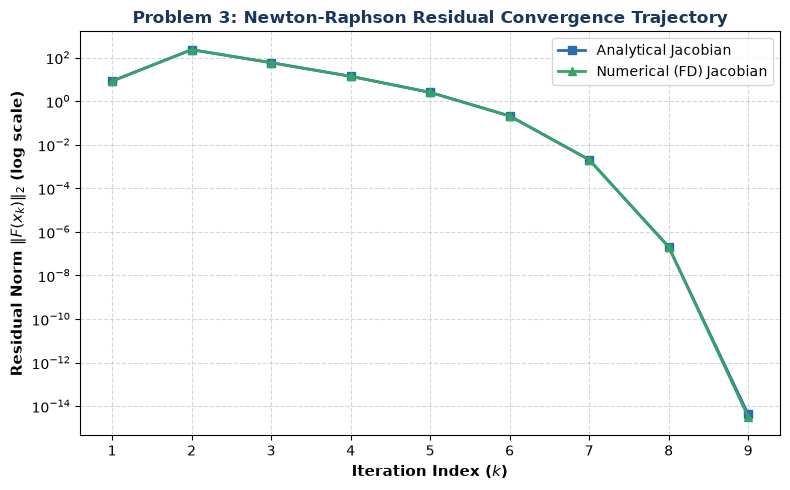

In [86]:
_, _, residuals_analytical = multivariable_newton_raphson(
    F_func, J_func, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


_, _, residuals_numerical = multivariable_newton_raphson_central(
    F_func, jacobian, x0=[1.0, 0.0, 0.0], tol=1e-10, max_iter=50, max_cond=1e12
)


plot(residuals_analytical, residuals_numerical)


### 3d Plot Trajectory

In [87]:
# ==========================================================
# PROBLEM 3: 3D Iteration Trajectory Plot
# ==========================================================
def plot_problem_3_3d_trajectory(trajectory_points):
    """
    Plots the 3D spatial path of Newton-Raphson iterates (x_k, y_k, z_k)
    converging toward the geometric intersection point.
    """
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d')

    traj = np.array(trajectory_points)
    xs, ys, zs = traj[:, 0], traj[:, 1], traj[:, 2]

    ax.plot(xs, ys, zs, 'o-', color='#E53E3E', lw=2, markersize=6,
            label='Newton Iterates')
    ax.scatter(xs[-1], ys[-1], zs[-1], color='#3182CE', s=120,
               marker='*', label='Converged Root')

    ax.set_xlabel('X Axis', fontweight='bold')
    ax.set_ylabel('Y Axis', fontweight='bold')
    ax.set_zlabel('Z Axis', fontweight='bold')
    ax.set_title('Problem 3: 3D Iteration Trajectory toward Intersection',
                 fontsize=12, fontweight='bold', color='#1A365D')
    ax.legend()
    plt.tight_layout()
    plt.savefig('problem_3_3d_trajectory.png', dpi=300)
    plt.show()


Converged root: [ 1.59558269 -0.95126071  2.35567802]


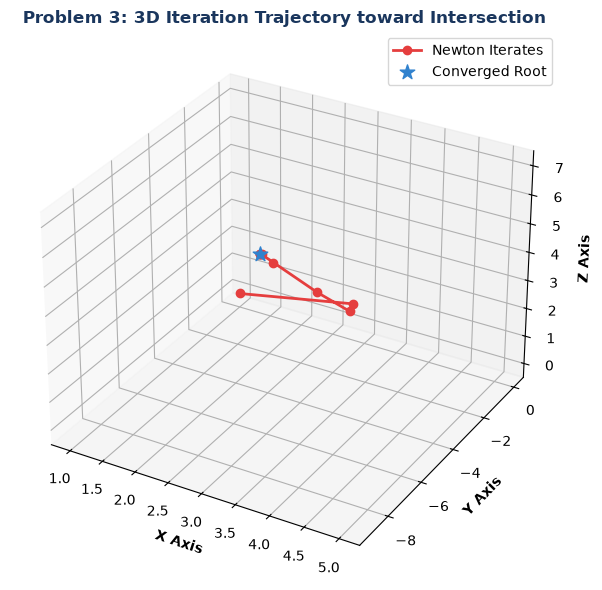

In [88]:
def F3d(v):
    x, y, z = v
    return np.array([x**2 + y**2 + z**2 - 9,
                     x**2 + 2*y**2 - z - 2,
                     x + y + z - 3
                     ], dtype=float)

def J3d(v):
    x, y, z = v
    return np.array([[2*x, 2*y, 2*z],
                      [2*x, 4*y, -1],
                      [1, 1, 1]
                      ], dtype=float)


def newton_with_trajectory(F_func, J_func, x0, tol=1e-10, max_iter=50):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for k in range(1, max_iter + 1):
        F = F_func(x)
        if vector_norm(F, 2) < tol:
            break
        J = J_func(x)
        delta_x = gaussian_elimination_solve(J, -F)
        x = x + delta_x
        traj.append(x.copy())
        if vector_norm(delta_x, 2) < tol:
            break
    return x, traj

root3d, trajectory_points = newton_with_trajectory(F3d, J3d, x0=[1.0, 0.0, 0.0])

print("Converged root:", root3d)
plot_problem_3_3d_trajectory(trajectory_points)


In [ ]:
import numpy as np
def compute_divided_diff_matrix(x,y):
    n=len(y)
    coef=np.zeroes([n,n])
    coef[:,0]=y
    
    for j in range(1,n):
        for i in range(n,-j):
            coef[i][j]=(coef[i+1][j-1]-coef[i][j-1])/(x[j+1]-x[i+1])
return coef 

def evaluate_newton_poly(coef,x_data,x_val):
    n=len(x_data)-1
    p=coef[n,n]
    for k in range(1,n+1):
        p=coef[n-k,n-k]+(x_val-x_data[n-k])*p
    return p

temp_sensor=np.array[45.0,10.0,25.0,60.0,80.0]
density_sensor=np.aarray[845.2,870.1,858.3,858.3,833.0,815.4]

table=compute_divided_diff_matrix(temp_sensor,density_sensor)
print("predicted Density at 30 C:",evaluate_newton_poly(table,temp_sensor,30.0))

: 

Problem 3